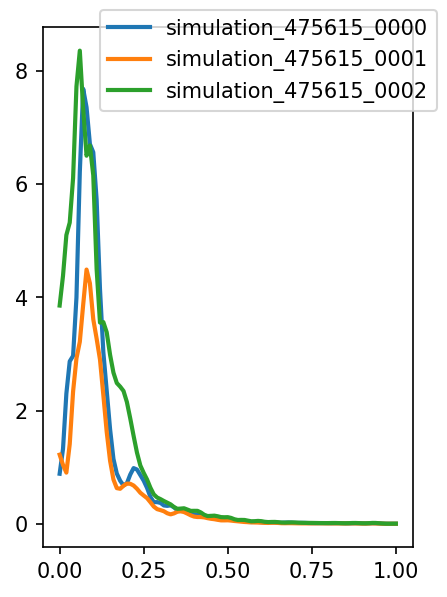

In [1]:
from netCDF4 import Dataset
from sys import argv
import os
import matplotlib.pyplot as plt

plot_var = 'paux'

fig, ax1 = plt.subplots(1,1,figsize = (3,4),dpi = 150)

# First just find the fastran.nc file ================
cwd = os.getcwd()
SCAN_dir = cwd+'/SCAN'
sims = [f for f in os.listdir(SCAN_dir) if f.startswith('simulation_') and not f.endswith('.conf') and not f.endswith('log')]

for sim in sims:
    work_dir = SCAN_dir+'/'+sim+'/work'
    fastran_dir = [f for f in os.listdir(work_dir) if f.startswith('fastran_tr_')]
    ffile = work_dir+'/'+fastran_dir[0]+'/fastran.nc'
#=====================================================

    rootgrp = Dataset(ffile)

    rho = rootgrp['rho'][:]

    ne = rootgrp['ne'][-1,:]
    nebar = rootgrp['nebar'][-1]
    ni = rootgrp['ni'][-1,:]

    te = rootgrp['te'][-1,:]
    teavg = rootgrp['tea'][-1]
    ti = rootgrp['ti'][-1,:]
    tiavg = rootgrp['tia'][-1]

    ipol = rootgrp['ipol'][-1,:]
    ip = rootgrp['ip'][-1]

    prfe = rootgrp['pe_rf'][-1,:]
    prfi = rootgrp['pi_rf'][-1,:]

    pfuse = rootgrp['pe_fus'][-1,:]
    pfuse_int = rootgrp['pfuse'][-1]
    pfusi = rootgrp['pi_fus'][-1,:]
    pfusi_int = rootgrp['pfusi'][-1]

    q = rootgrp['q'][-1,:]

    jbs = rootgrp['j_bs'][-1,:]
    ibs = rootgrp['ibs'][-1]
    jrf = rootgrp['j_rf'][-1,:]
    irf = rootgrp['irf'][-1]
    jtot = rootgrp['j_tot'][-1,:]

    fluxe = rootgrp['fluxe'][-1,:]
    fluxe_exp = rootgrp['fluxe_exp'][-1,:]
    fluxi = rootgrp['fluxi'][-1,:]
    fluxi_exp = rootgrp['fluxi_exp'][-1,:]

    var_dic = {'ne':ne,'ni':ni,'te':te,'ti':ti,'ipol':ipol,'jbs':jbs,'jrf':jrf,'pfus':5*(pfuse+pfusi),'paux':prfe+prfi}
    lw = 2
    c1 = 'green'
    c2 = 'lime'
    c3 = 'magenta'
    c4 = 'darkviolet'
    c5 = 'dodgerblue'
    c6 = 'cyan'
    
    ax1.plot(rho,var_dic[plot_var], linewidth = lw, label = sim)

fig.tight_layout()
fig.legend()
plt.show()

